## **Deep Learning based Antimicrobial Susceptibility Phenotyping Detection**

Dataset Link: https://ora.ox.ac.uk/objects/uuid:12153432-e8b3-4398-a395-abfb980bd84e

#### **Libraries**

In [1]:
import os
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf

warnings.filterwarnings('ignore')

#### **Count of Images from each folder**

In [2]:
raw_parent_dir = "Data/MG1655/All_images"
folder_names = ['WT+ETOH', 'CIP+ETOH', 'GENT+ETOH', 'RIF+ETOH', 'COAMOX+ETOH']
for f in folder_names:
    old_name = os.path.join(raw_parent_dir, f)
    new_name = os.path.join(raw_parent_dir, f.split("+")[0])
    os.rename(old_name, new_name)
    count_of_images = len(os.listdir(os.path.join(raw_parent_dir, f.split("+")[0])))
    print(f"{new_name} has {count_of_images} images")

Data/MG1655/All_images\WT has 455 images
Data/MG1655/All_images\CIP has 285 images
Data/MG1655/All_images\GENT has 199 images
Data/MG1655/All_images\RIF has 279 images
Data/MG1655/All_images\COAMOX has 350 images


#### **Complete Data about the tif file**

In [4]:
from PIL import Image
import tifffile

# Path to one image
main_path = os.path.join(raw_parent_dir, "WT/")
img_name = os.listdir(main_path)[0]
img_path = os.path.join(main_path, img_name)

print("Image Path:", img_path)
print("-"*50)

img_pil = Image.open(img_path)

img_array = np.array(img_pil)

print("\nNumPy Information")
print("Shape:", img_array.shape)
print("Data type:", img_array.dtype)

with tifffile.TiffFile(img_path) as tif:
    print("\nTIFF Metadata")
    print("Image shape:", tif.pages[0].shape)
    print("Image dtype:", tif.pages[0].dtype)

Image Path: Data/MG1655/All_images\WT/200818_1_MG1655_NA_AMR_combined_1_WT+ETOH_posXY0.tif
--------------------------------------------------

NumPy Information
Shape: (684, 420, 3)
Data type: uint8

TIFF Metadata
Image shape: (3, 684, 420)
Image dtype: uint16


#### **Sample image from Each Type**

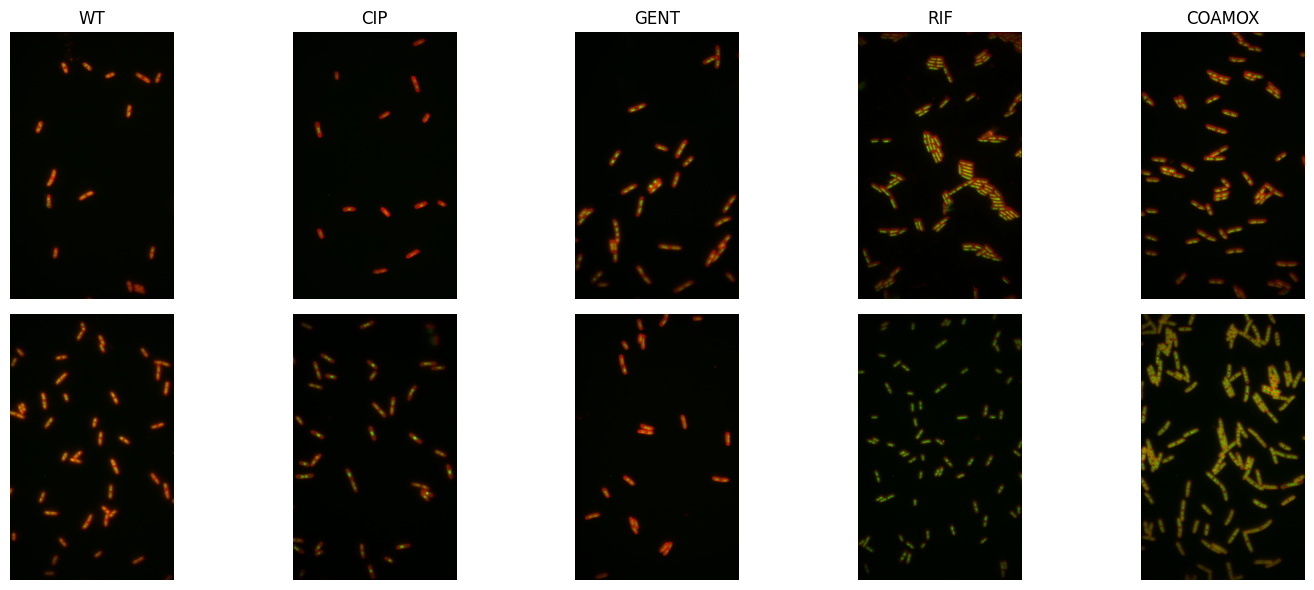

In [ ]:
import random

base_path = raw_parent_dir
classes = ["WT", "CIP", "GENT", "RIF", "COAMOX"]

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))

for col, cls in enumerate(classes):
    
    class_path = os.path.join(base_path, cls)
    images = [f for f in os.listdir(class_path) if f.endswith(".tif")]
    
    selected = random.sample(images, 2)
    
    for row in range(2):
        
        img_path = os.path.join(class_path, selected[row])
        img = tifffile.imread(img_path)
        
        # (3, H, W) → (H, W, 3)
        img = np.transpose(img, (1, 2, 0))
        
        # Normalize safely
        img = img.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        
        # Add class title only on top row
        if row == 0:
            axes[row, col].set_title(cls, fontsize=12)

plt.tight_layout()
plt.show()

#### **Data Split**

In [10]:
# Paths
source_dir = raw_parent_dir
target_dir = "intermediate"

# Create folder structure
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(target_dir, split, cls), exist_ok=True)

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for cls in classes:
    class_path = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(class_path) if f.endswith(".tif")]
    
    random.shuffle(images)
    
    total = len(images)
    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)
    
    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]
    
    # Copy files
    for img in train_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "train", cls, img)
        )
        
    for img in val_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "val", cls, img)
        )
        
    for img in test_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "test", cls, img)
        )

print("Dataset successfully split into Train (70%), Val (15%), Test (15%)")

Dataset successfully split into Train (70%), Val (15%), Test (15%)


#### **Data After Train, Test and Validation split**

In [11]:
train_parent_dir = r"intermediate/train"
print("Count of Images for each class in train directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(train_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in train directory
WT has 318 images
CIP has 199 images
GENT has 139 images
RIF has 195 images
COAMOX has 244 images


In [13]:
val_parent_dir = "intermediate/val"
print("Count of Images for each class in val directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(val_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in val directory
WT has 68 images
CIP has 42 images
GENT has 29 images
RIF has 41 images
COAMOX has 52 images


In [14]:
test_parent_dir = "intermediate/test"
print("Count of Images for each class in test directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(test_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in test directory
WT has 69 images
CIP has 44 images
GENT has 31 images
RIF has 43 images
COAMOX has 54 images


#### **Segmentation**

**Checking Nile Red Index**

intermediate/train\WT/200818_1_MG1655_NA_AMR_combined_1_WT+ETOH_posXY1.tif
Shape: (3, 684, 420)
Dtype: uint16


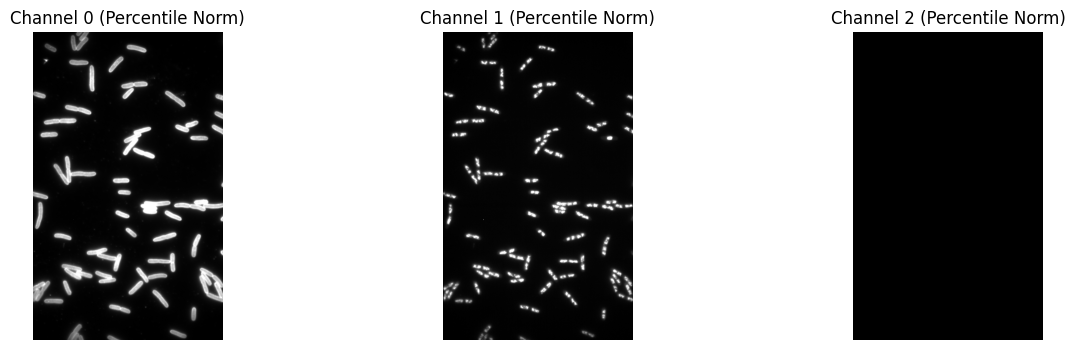

In [17]:
main_path = os.path.join(train_parent_dir, "WT/")
img_name = os.listdir(main_path)[0]
print(main_path+img_name)
img_path = os.path.join(main_path, img_name)

img = tifffile.imread(img_path)

print("Shape:", img.shape)
print("Dtype:", img.dtype)

plt.figure(figsize=(15,4))

for i in range(3):
    channel = img[i].astype(np.float32)
    
    p1, p99 = np.percentile(channel, (1, 99))
    channel = np.clip(channel, p1, p99)
    channel = (channel - p1) / (p99 - p1 + 1e-8)
    
    plt.subplot(1,3,i+1)
    plt.imshow(channel, cmap='gray')
    plt.title(f"Channel {i} (Percentile Norm)")
    plt.axis("off")

plt.show()

**Testing on Sample Image from train WT**

Number of detected cells: 36


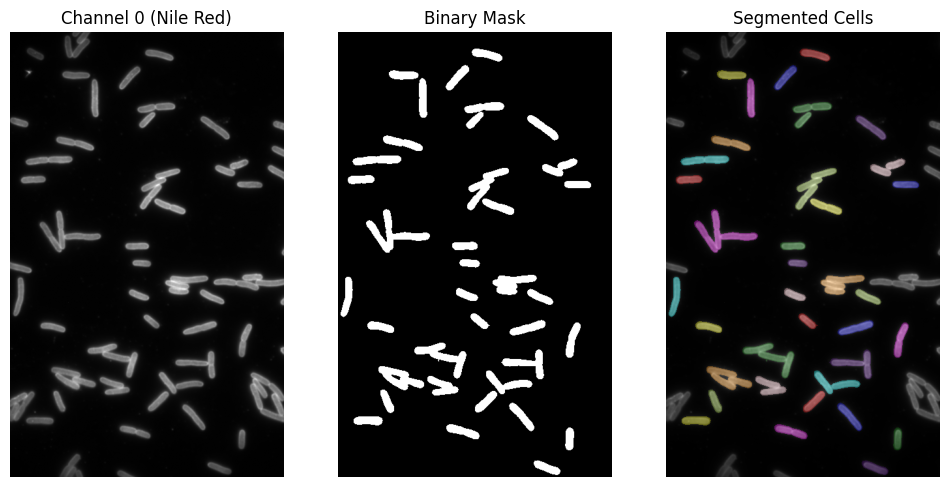

In [18]:
from skimage import filters, morphology, measure
from skimage.segmentation import clear_border
from skimage.color import label2rgb


img = tifffile.imread(img_path)

# From above plot we can clearly say that Channel 0 separates cells from background. So nile is at index 0
nile = img[0]

# Normalize to 0–255
nile_norm = cv2.normalize(nile, None, 0, 255, cv2.NORM_MINMAX)
nile_norm = nile_norm.astype(np.uint8)

from skimage.filters import threshold_local

block_size = 51   # must be odd
adaptive_thresh = threshold_local(nile_norm, block_size, offset=5)

binary = nile_norm > adaptive_thresh
binary = morphology.remove_small_objects(binary, min_size=100)
binary = clear_border(binary)

# Label
labels = measure.label(binary)
regions = measure.regionprops(labels)

print("Number of detected cells:", len(regions))

# Overlay
overlay = label2rgb(labels, image=nile_norm, bg_label=0)

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(nile_norm, cmap='gray')
plt.title("Channel 0 (Nile Red)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(binary, cmap='gray')
plt.title("Binary Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Segmented Cells")
plt.axis("off")

plt.show()

**Segmenting Train, Val and Test Data**

In [23]:
from skimage import morphology, measure
from skimage.segmentation import clear_border, watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi

BASE_PATH = "intermediate"
DST_PATH = "segmented images"
SPLITS = ["train", "val", "test"]

NILE_CHANNEL = 0
MIN_CELL_AREA = 200
RESIZE_SIZE = 128

# Create CLAHE once (faster)
CLAHE = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

In [24]:
def pad_to_square(img):
    h, w, c = img.shape
    size = max(h, w)
    padded = np.zeros((size, size, c), dtype=img.dtype)
    
    y_off = (size - h) // 2
    x_off = (size - w) // 2
    
    padded[y_off:y_off+h, x_off:x_off+w] = img
    return padded

In [25]:
# Segmentation Function
def segment_cells(nile_img):
    
    # Normalize
    nile = cv2.normalize(nile_img, None, 0, 255, cv2.NORM_MINMAX)
    nile = nile.astype(np.uint8)

    # CLAHE
    enhanced = CLAHE.apply(nile)

    # Blur
    blur = cv2.GaussianBlur(enhanced, (3,3), 0)

    # Adaptive threshold
    adaptive = cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        51, 5
    )

    binary = adaptive.astype(bool)

    # Morphology
    binary = morphology.remove_small_objects(binary, min_size=100)
    binary = morphology.remove_small_holes(binary, area_threshold=100)
    binary = clear_border(binary)

    if np.sum(binary) == 0:
        return None

    # Distance transform
    distance = ndi.distance_transform_edt(binary)

    # Improved marker detection
    local_max = peak_local_max(
        distance,
        min_distance=10,
        labels=binary
    )

    markers = np.zeros_like(distance, dtype=np.int32)
    markers[tuple(local_max.T)] = np.arange(1, len(local_max)+1)

    labels = watershed(-distance, markers, mask=binary)

    return labels

In [27]:
for split in SPLITS:

    print(f"\nProcessing {split} set...")

    input_split = os.path.join(BASE_PATH, split)
    output_split = os.path.join(DST_PATH, f"{split}_segmented")

    for cls in classes:

        input_class = os.path.join(input_split, cls)
        output_class = os.path.join(output_split, cls)
        os.makedirs(output_class, exist_ok=True)

        images = [f for f in os.listdir(input_class) if f.endswith(".tif")]

        cell_id = 0

        for img_name in images:

            img_path = os.path.join(input_class, img_name)

            try:
                img = tifffile.imread(img_path)
            except:
                continue

            nile = img[NILE_CHANNEL]

            labels = segment_cells(nile)

            if labels is None:
                continue

            regions = measure.regionprops(labels)

            full_img = np.transpose(img, (1,2,0))

            for region in regions:

                if region.area < MIN_CELL_AREA:
                    continue

                if region.eccentricity < 0.6:
                    continue

                minr, minc, maxr, maxc = region.bbox

                crop = full_img[minr:maxr, minc:maxc]
                mask = (labels[minr:maxr, minc:maxc] == region.label)

                # Apply mask safely
                crop = crop.copy()
                crop[~mask] = 0

                # Pad + resize
                crop = pad_to_square(crop)
                crop = cv2.resize(crop, (RESIZE_SIZE, RESIZE_SIZE))

                save_name = f"{cls}_{img_name[:-4]}_cell_{cell_id}.png"
                save_path = os.path.join(output_class, save_name)

                cv2.imwrite(save_path, cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))

                cell_id += 1

        print(f"{cls}: {cell_id} cells saved")


Processing train set...
WT: 11637 cells saved
CIP: 6633 cells saved
GENT: 5912 cells saved
RIF: 8401 cells saved
COAMOX: 5678 cells saved

Processing val set...
WT: 3061 cells saved
CIP: 1457 cells saved
GENT: 1425 cells saved
RIF: 1798 cells saved
COAMOX: 1435 cells saved

Processing test set...
WT: 2315 cells saved
CIP: 1657 cells saved
GENT: 1439 cells saved
RIF: 2157 cells saved
COAMOX: 1217 cells saved


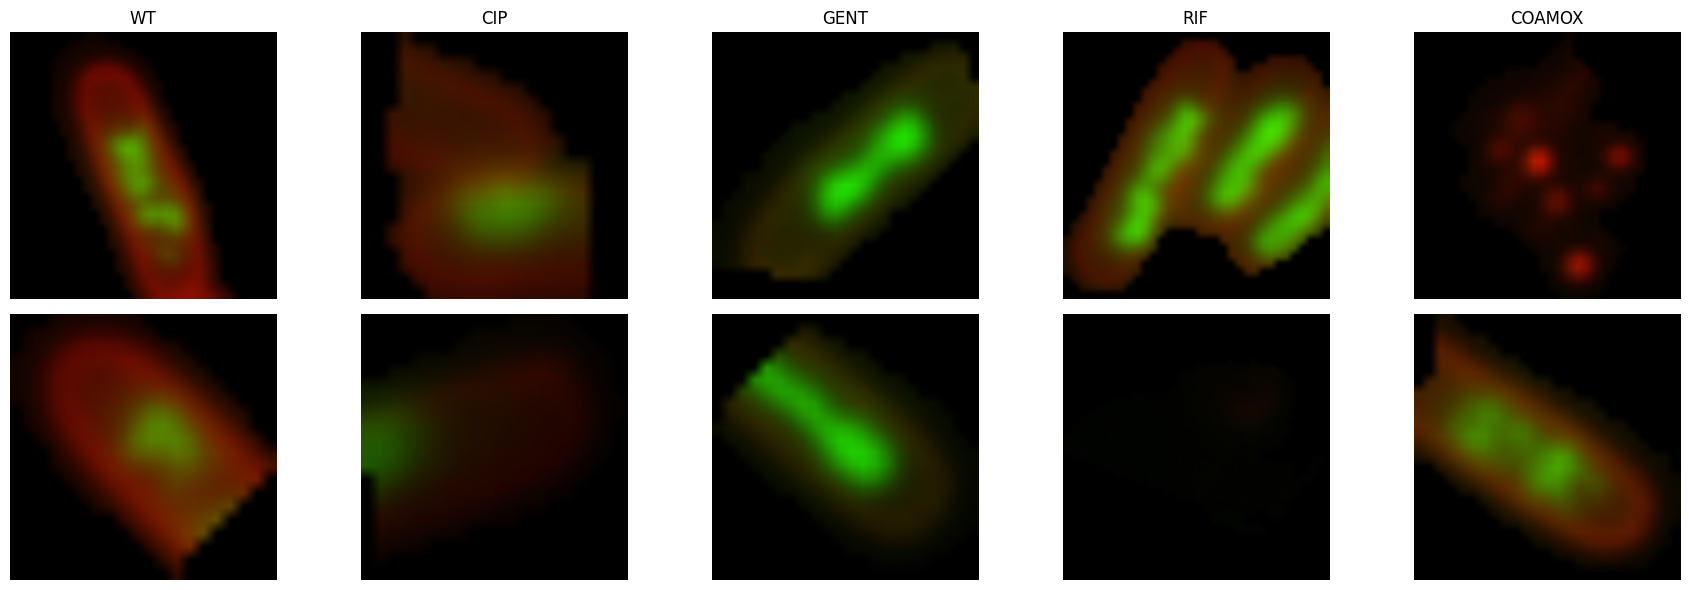

In [29]:
import matplotlib.image as mpimg

data_dir = 'segmented images/train_segmented'

fig, axes = plt.subplots(2, 5, figsize=(18, 6))

for col, cls in enumerate(classes):
    
    cls_path = os.path.join(data_dir, cls)
    
    # Get sorted images
    images = sorted([f for f in os.listdir(cls_path) if f.endswith(".png")])
    
    # Take first 2 images
    first_two = images[1:3]
    
    for row in range(2):
        
        img_path = os.path.join(cls_path, first_two[row])
        img = mpimg.imread(img_path)
        
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        
        # Add class title only on top row
        if row == 0:
            axes[row, col].set_title(cls, fontsize=12)

plt.tight_layout()
plt.show()

## **Models**

#### **Model 1**

#### **Model 2**

#### **Model 3**